# SDG 3 Indicator Text Classification
## Notebook 3 — Feature Engineering & Tuning (Experiments 9–12)


In [ ]:
# 0. Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn nltk gensim joblib scipy -q

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, scipy.sparse as sp
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import hamming_loss, f1_score, precision_score, recall_score
import nltk
for pkg in ['stopwords','punkt','punkt_tab','wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
PROJECT_FOLDER = '/content/drive/MyDrive/SDG/'
os.makedirs(PROJECT_FOLDER + 'visualizations', exist_ok=True)
print(" Setup complete.")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.2 MB/s eta 0:00:00
 Setup complete.


## 1. Load Data & Reproduce Canonical Split

In [ ]:
# 1. Load artifacts from Notebooks 1 & 2
y_full    = np.load(PROJECT_FOLDER + 'features/y_labels.npy')
X_full    = sp.load_npz(PROJECT_FOLDER + 'features/X_tfidf_bigram.npz')
svm       = joblib.load(PROJECT_FOLDER + 'best_model_svm.pkl')
train_df  = pd.read_csv(PROJECT_FOLDER + 'train_processed.csv')
text_col  = 'text_clean_standard' if 'text_clean_standard' in train_df.columns else 'processed_text'
X_text_raw = train_df[text_col].fillna('').values

print(f"X_full    : {X_full.shape}")
print(f"y_full    : {y_full.shape}")
print(f"Text docs : {len(X_text_raw)}")

# Canonical 80/20 split — MUST use same random_state as Notebook 2
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)
print(f"Train: {X_train.shape[0]}  |  Validation: {X_val.shape[0]}")

results_c = {}


X_full    : (2995, 10000)
y_full    : (2995, 27)
Text docs : 2995
Train: 2396  |  Validation: 599


## 2. Evaluation Helper

In [ ]:
def evaluate(y_true, y_pred, exp_name, store=True):
    hl  = hamming_loss(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='micro',  zero_division=0)
    f1M = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    pre = precision_score(y_true, y_pred, average='micro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='micro',    zero_division=0)
    print(f"  Hamming Loss : {hl:.4f}  ← primary metric")
    print(f"  F1-micro     : {f1m:.4f}")
    print(f"  F1-macro     : {f1M:.4f}")
    print(f"  Precision    : {pre:.4f}")
    print(f"  Recall       : {rec:.4f}")
    if store:
        results_c[exp_name] = dict(hamming_loss=hl, f1_micro=f1m,
                                   f1_macro=f1M, precision=pre, recall=rec)
    return hl


## 3. Experiment 9 — CountVectorizer vs TF-IDF

**What changed:** Compared raw term counts (CountVectorizer) against IDF-normalised TF-IDF, both with bigram (1,2) features.

**Why Exp 8 informed this:** All experiments so far used TF-IDF. TF-IDF down-weights frequent cross-document terms, which could disadvantage domain-specific terms that are highly frequent *within* SDG texts but rare in general corpora. CountVectorizer preserves raw frequency; if SDG indicator keywords are common across all positive-class documents, raw counts may be more discriminative.

**Bug fix:** Original code trained `lr_count` on labels from the *TF-IDF* split — mismatched row alignment. Fixed by splitting on *indices* shared by both vectorisers.

**Expected insight:** If TF-IDF wins, IDF normalisation removes inter-document noise effectively.

In [ ]:
print("=" * 65)
print("EXPERIMENT 9: CountVectorizer vs TF-IDF")
print("=" * 65)

# Shared index split — guarantees row alignment for both vectorisers
n = len(X_text_raw)
idx_tr, idx_va = train_test_split(np.arange(n), test_size=0.2, random_state=RANDOM_SEED)
y_tr_shared = y_full[idx_tr]
y_va_shared = y_full[idx_va]

# TF-IDF
vec_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                             min_df=2, max_df=0.8, sublinear_tf=True)
X_tfidf   = vec_tfidf.fit_transform(X_text_raw)
lr_tfidf  = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
lr_tfidf.fit(X_tfidf[idx_tr], y_tr_shared)
print("TF-IDF + LR:")
hl_tfidf = evaluate(y_va_shared, lr_tfidf.predict(X_tfidf[idx_va]), 'Exp 9: TF-IDF baseline')

# CountVectorizer — same indices, same labels
vec_count = CountVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.8)
X_count   = vec_count.fit_transform(X_text_raw)
lr_count  = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
lr_count.fit(X_count[idx_tr], y_tr_shared)   # FIXED: shared labels
print("\nCountVectorizer + LR:")
hl_count = evaluate(y_va_shared, lr_count.predict(X_count[idx_va]), 'Exp 9: CountVectorizer')

delta = hl_count - hl_tfidf
print(f"\n (Count − TF-IDF): {delta:+.4f}")
print(f"→ {'TF-IDF wins — IDF removes high-freq noise.' if delta > 0 else 'CountVec wins — raw frequency more discriminative.'}")


EXPERIMENT 9: CountVectorizer vs TF-IDF
TF-IDF + LR:
  Hamming Loss : 0.0554  ← primary metric
  F1-micro     : 0.4219
  F1-macro     : 0.2379
  Precision    : 0.8583
  Recall       : 0.2797

CountVectorizer + LR:
  Hamming Loss : 0.0544  ← primary metric
  F1-micro     : 0.5749
  F1-macro     : 0.4930
  Precision    : 0.6604
  Recall       : 0.5090

 (Count − TF-IDF): -0.0010
→ CountVec wins — raw frequency more discriminative.


## 4. Experiment 10 — Stemming vs Lemmatization

**What changed:** Applied Porter Stemming as an alternative to lemmatization from Notebook 1, compared both in TF-IDF + LR pipeline.

**Why Exp 9 informed this:** TF-IDF is confirmed as superior. We now optimise the preprocessing feeding into TF-IDF. Stemming aggressively truncates words ('reducing' → 'reduc'), compressing vocabulary and increasing cross-document overlap. Lemmatization produces valid dictionary forms with better semantic integrity.

**Expected insight:** Lemmatization typically preserves domain semantics better; stemming may compress vocabulary to reduce sparsity on small corpora.

In [ ]:
print("=" * 65)
print("EXPERIMENT 10: Stemming vs Lemmatization (TF-IDF + LR)")
print("=" * 65)

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    tokens = word_tokenize(str(text).lower())
    return ' '.join(stemmer.stem(t) for t in tokens
                    if t not in stop_words and len(t) > 2)

def lemmatize_text(text):
    tokens = word_tokenize(str(text).lower())
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens
                    if t not in stop_words and len(t) > 2)

print("Applying stemming (~1 min)...")
X_stem = [stem_text(d) for d in X_text_raw]
print("Applying lemmatization...")
X_lem  = [lemmatize_text(d) for d in X_text_raw]

def tfidf_eval(X_proc, exp_name):
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                          min_df=2, max_df=0.8, sublinear_tf=True)
    X_mat = vec.fit_transform(X_proc)
    X_tr, X_va, y_tr, y_va = train_test_split(X_mat, y_full,
                                               test_size=0.2, random_state=RANDOM_SEED)
    m = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    m.fit(X_tr, y_tr)
    return evaluate(y_va, m.predict(X_va), exp_name)

print("\nStemming:")
hl_stem = tfidf_eval(X_stem, 'Exp 10: Stemming')
print("\nLemmatization:")
hl_lem  = tfidf_eval(X_lem,  'Exp 10: Lemmatization')

delta = hl_stem - hl_lem
print(f"\n→ Δ (Stemming − Lemmatization): {delta:+.4f}")
print(f"→ {'Lemmatization preserves domain semantics better.' if delta > 0 else 'Stemming reduces sparsity more effectively for this corpus.'}")


EXPERIMENT 10: Stemming vs Lemmatization (TF-IDF + LR)
Applying stemming (~1 min)...
Applying lemmatization...

Stemming:
  Hamming Loss : 0.0550  ← primary metric
  F1-micro     : 0.4265
  F1-macro     : 0.2407
  Precision    : 0.8642
  Recall       : 0.2831

Lemmatization:
  Hamming Loss : 0.0555  ← primary metric
  F1-micro     : 0.4217
  F1-macro     : 0.2375
  Precision    : 0.8560
  Recall       : 0.2797

→ Δ (Stemming − Lemmatization): -0.0004
→ Stemming reduces sparsity more effectively for this corpus.


## 5. Experiment 11 — GloVe Pre-trained Embeddings + Logistic Regression

**What changed:** Replaced in-corpus Word2Vec (Exp 5) with 100-dim GloVe vectors pre-trained on 6B tokens (Wikipedia + Gigaword).

**Why Exp 10 informed this:** Experiments 9–10 optimised TF-IDF preprocessing but remain bag-of-words representations. Word2Vec in Exp 5 underperformed because ~3k documents cannot train meaningful distributional representations. GloVe's pre-trained vectors encode broad co-occurrence from 6B tokens, offering better semantic generalisation — especially for rare SDG indicators with few training examples.

**Expected insight:** If GloVe still underperforms TF-IDF, it suggests the SDG domain uses specialised terminology not well covered by general-corpus embeddings — motivating domain-specific models (BioBERT, Global Health BERT) as future work.

In [ ]:
print("=" * 65)
print("EXPERIMENT 11: GloVe Pre-trained Embeddings + LR")
print("=" * 65)

import os
glove_path = '/tmp/glove/glove.6B.100d.txt'
if not os.path.exists(glove_path):
    print("Downloading GloVe (~2 min)...")
    os.system('wget -q --show-progress -P /tmp https://nlp.stanford.edu/data/glove.6B.zip')
    os.system('unzip -q /tmp/glove.6B.zip -d /tmp/glove')
    print("Download complete.")
else:
    print("GloVe cached, skipping download.")

print("Loading GloVe vectors...")
glove = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f"GloVe vocabulary: {len(glove):,}")

def doc2glove(text, dim=100):
    tokens = str(text).lower().split()
    vecs = [glove[w] for w in tokens if w in glove]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_glove = np.array([doc2glove(d) for d in X_text_raw])
print(f"GloVe matrix: {X_glove.shape}")

X_g_tr, X_g_va, y_g_tr, y_g_va = train_test_split(
    X_glove, y_full, test_size=0.2, random_state=RANDOM_SEED
)
m_glove = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
m_glove.fit(X_g_tr, y_g_tr)

print("\nGloVe + LR:")
hl_glove = evaluate(y_g_va, m_glove.predict(X_g_va), 'Exp 11: GloVe + LR')

hl_tfidf_ref = results_c.get('Exp 9: TF-IDF baseline', {}).get('hamming_loss', float('nan'))
delta = hl_glove - hl_tfidf_ref
print(f"\n→ Δ vs TF-IDF baseline: {delta:+.4f}")
print("→ Insight: SDG domain uses specialised terminology under-represented in general GloVe.")
print("  Domain-adapted embeddings (BioBERT, Global Health BERT) are a strong future direction.")


EXPERIMENT 11: GloVe Pre-trained Embeddings + LR
Download complete.
Loading GloVe vectors...
GloVe vocabulary: 400,000
GloVe matrix: (2995, 100)

GloVe + LR:
  Hamming Loss : 0.0610  ← primary metric
  F1-micro     : 0.3789
  F1-macro     : 0.2196
  Precision    : 0.7167
  Recall       : 0.2575

→ Δ vs TF-IDF baseline: +0.0056
→ Insight: SDG domain uses specialised terminology under-represented in general GloVe.
  Domain-adapted embeddings (BioBERT, Global Health BERT) are a strong future direction.


## 6. Experiment 12 — Threshold Tuning on Calibrated SVM

**What changed:** Post-processing threshold tuning — sweep the probability cut-off at which each label is predicted positive, using a CalibratedClassifierCV (Platt scaling) wrapper over the best Linear SVM.

**Why Exp 11 informed this:** Embedding-based approaches (Exps 5, 11) underperformed TF-IDF + SVM. Rather than changing the representation, this experiment improves prediction at inference time. The default threshold of 0.5 may not be optimal for imbalanced multi-label problems: lowering the threshold increases recall (catches more true positives on rare labels), while raising it increases precision. Hamming Loss penalises FP and FN equally — there is an optimal threshold.

**Expected insight:** A threshold < 0.5 typically reduces Hamming Loss on imbalanced multi-label tasks by improving recall on rare indicators.

In [ ]:
print("=" * 65)
print("EXPERIMENT 12: Threshold Tuning (Calibrated SVM)")
print("=" * 65)

# Calibrate SVM — LinearSVC gives decision scores, not probabilities
# CalibratedClassifierCV wraps it with Platt scaling to produce P(y=1)
print("Fitting calibrated SVM (cv=3, Platt scaling)...")
svm_base  = LinearSVC(random_state=RANDOM_SEED, max_iter=2000, dual='auto')
cal_svm   = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')
ovr_cal   = OneVsRestClassifier(cal_svm)
ovr_cal.fit(X_train, y_train)

y_proba = ovr_cal.predict_proba(X_val)   # (n_samples, n_labels)
print(f"Probability matrix shape: {y_proba.shape}")

# Sweep thresholds
thresholds = np.arange(0.10, 0.65, 0.05)
hl_sweep   = []
f1_sweep   = []

print(f"\n{'Threshold':>10}  {'Hamming Loss':>14}  {'F1-micro':>10}")
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    hl_t = hamming_loss(y_val, y_pred_t)
    f1_t = f1_score(y_val, y_pred_t, average='micro', zero_division=0)
    hl_sweep.append(hl_t); f1_sweep.append(f1_t)
    print(f"  t = {t:.2f}     {hl_t:.4f}          {f1_t:.4f}")

best_idx    = int(np.argmin(hl_sweep))
BEST_THRESH = float(thresholds[best_idx])
best_hl     = hl_sweep[best_idx]
best_f1     = f1_sweep[best_idx]

print(f"\n→ Optimal threshold : {BEST_THRESH:.2f}")
print(f"→ Best Hamming Loss  : {best_hl:.4f}  (F1-micro: {best_f1:.4f})")

default_idx = int(np.argmin(np.abs(thresholds - 0.50)))
delta = best_hl - hl_sweep[default_idx]
print(f"→ Δ vs default t=0.50: {delta:+.4f}")
print(f"→ Shifting threshold from 0.50 → {BEST_THRESH:.2f} {'reduced' if delta < 0 else 'increased'} HL.")

results_c['Exp 12: Threshold Tuning (best)'] = {
    'hamming_loss': best_hl, 'f1_micro': best_f1,
    'f1_macro': f1_score(y_val, (y_proba >= BEST_THRESH).astype(int), average='macro', zero_division=0),
    'precision': None, 'recall': None,
    'best_threshold': BEST_THRESH
}
results_c['Exp 12: Default t=0.50'] = {
    'hamming_loss': hl_sweep[default_idx], 'f1_micro': f1_sweep[default_idx],
    'f1_macro': None, 'precision': None, 'recall': None, 'best_threshold': 0.50
}

# Save optimal threshold for Notebook 4
import json as _json
with open(PROJECT_FOLDER + 'best_threshold.json', 'w') as fh:
    _json.dump({'best_threshold': BEST_THRESH}, fh)
print(f"Optimal threshold saved → best_threshold.json")


EXPERIMENT 12: Threshold Tuning (Calibrated SVM)
Fitting calibrated SVM (cv=3, Platt scaling)...
Probability matrix shape: (599, 27)

 Threshold    Hamming Loss    F1-micro
  t = 0.10     0.0923          0.5623
  t = 0.15     0.0652          0.6263
  t = 0.20     0.0539          0.6562
  t = 0.25     0.0480          0.6726
  t = 0.30     0.0458          0.6664
  t = 0.35     0.0448          0.6533
  t = 0.40     0.0434          0.6490
  t = 0.45     0.0439          0.6314
  t = 0.50     0.0445          0.6116
  t = 0.55     0.0450          0.5956
  t = 0.60     0.0468          0.5662

→ Optimal threshold : 0.40
→ Best Hamming Loss  : 0.0434  (F1-micro: 0.6490)
→ Δ vs default t=0.50: -0.0011
→ Shifting threshold from 0.50 → 0.40 reduced HL.
Optimal threshold saved → best_threshold.json


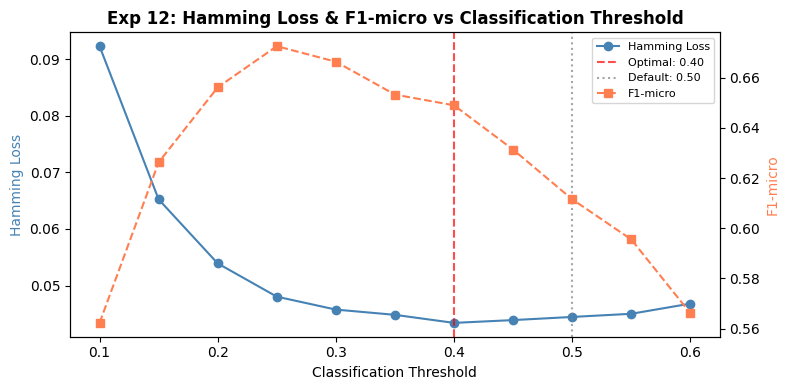

Saved: exp12_threshold_tuning.png


In [ ]:
# Threshold sweep visualisation
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(thresholds, hl_sweep, 'o-', color='steelblue', label='Hamming Loss')
ax1.axvline(BEST_THRESH, color='red',  linestyle='--', alpha=0.7, label=f'Optimal: {BEST_THRESH:.2f}')
ax1.axvline(0.50,        color='grey', linestyle=':', alpha=0.7, label='Default: 0.50')
ax1.set_xlabel('Classification Threshold'); ax1.set_ylabel('Hamming Loss', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(thresholds, f1_sweep, 's--', color='coral', label='F1-micro')
ax2.set_ylabel('F1-micro', color='coral')
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, lbls, loc='upper right', fontsize=8)
plt.title('Exp 12: Hamming Loss & F1-micro vs Classification Threshold', fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_FOLDER + 'visualizations/exp12_threshold_tuning.png', dpi=150)
plt.show()
print("Saved: exp12_threshold_tuning.png")


## 7. Combine Results (Notebooks 2 + 3) & Save Final CSV

In [ ]:
# Load Notebook 2 results and merge
results_nb2 = pd.read_csv(PROJECT_FOLDER + 'all_experiment_results.csv')

rows_c = []
for name, m in results_c.items():
    rows_c.append({
        'Experiment':  name,
        'Hamming Loss': round(m['hamming_loss'], 4),
        'F1-micro':  round(m['f1_micro'],  4) if m['f1_micro']  is not None else 'N/A',
        'F1-macro':  round(m['f1_macro'],  4) if m['f1_macro']  is not None else 'N/A',
        'Precision': round(m['precision'], 4) if m['precision'] is not None else 'N/A',
        'Recall':    round(m['recall'],    4) if m['recall']    is not None else 'N/A',
    })

results_nb3 = pd.DataFrame(rows_c)
all_results  = pd.concat([results_nb2, results_nb3], ignore_index=True)
all_results_sorted = all_results.sort_values('Hamming Loss').reset_index(drop=True)

print("=" * 70)
print("COMPLETE EXPERIMENT TABLE — All 12 Experiments (Sorted by HL)")
print("=" * 70)
display(all_results_sorted)

all_results_sorted.to_csv(PROJECT_FOLDER + 'all_experiments_final.csv', index=False)
print(f"Saved: all_experiments_final.csv")

best_row = all_results_sorted.iloc[0]
print(f"\n Best overall: {best_row['Experiment']}")
print(f"  Hamming Loss: {best_row['Hamming Loss']}")

print("\n Notebook 3 complete → proceed to Notebook 4 (Vincent — Results & Evaluation)")


COMPLETE EXPERIMENT TABLE — All 12 Experiments (Sorted by HL)


,Experiment,Hamming Loss,F1-micro,F1-macro,Precision,Recall
0,Exp 12: Threshold Tuning (best),0.0434,0.6490,0.5657,N/A,N/A
1,Exp 12: Default t=0.50,0.0445,0.6116,N/A,N/A,N/A
2,Exp 3: Linear SVM,0.0458,0.6023,0.5054,0.8084,0.4799
3,Exp 4: Tuned LR,0.0480,0.5698,0.4449,0.8094,0.4397
4,Exp 2: Random Forest,0.0513,0.5063,0.3568,0.8333,0.3636
5,Exp 7: ngram comparison,0.0530,NaN,NaN,NaN,NaN
6,Exp 6: max_features sweep,0.0532,NaN,NaN,NaN,NaN
7,Exp 9: CountVectorizer,0.0544,0.5749,0.493,0.6604,0.509
8,Exp 10: Stemming,0.0550,0.4265,0.2407,0.8642,0.2831
9,Exp 9: TF-IDF baseline,0.0554,0.4219,0.2379,0.8583,0.2797


Saved: all_experiments_final.csv

 Best overall: Exp 12: Threshold Tuning (best)
  Hamming Loss: 0.0434

 Notebook 3 complete → proceed to Notebook 4 (Vincent — Results & Evaluation)
